# Projeto a CallMeMaybe

## Tarefa: Identificar operadores com resultados menos expressivos

### Etapa 1. Pré-processamento

In [1]:
# bibliotecas
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

In [2]:
# dataframes
telecom_dataset = pd.read_csv('telecom_dataset_new.csv')
clients = pd.read_csv('telecom_clients.csv')

In [3]:
print('Telecom Dataset')
print(telecom_dataset.info())
print('')
print('Telecom Clients')
print(clients.info())

Telecom Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
None

Telecom Clients
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   t

In [4]:
# estudando telecom_clients
print(f"Linhas duplicadas: {clients.duplicated().sum()}.")
print(f"Usuários únicos: {clients['user_id'].nunique()}.")
print(f"Opções de tarifário: {clients['tariff_plan'].unique()}.")

Linhas duplicadas: 0.
Usuários únicos: 732.
Opções de tarifário: ['A' 'C' 'B'].


In [5]:
# corrigindo tipo de dado da coluna e imprimindo amostra
clients['date_start'] = pd.to_datetime(clients['date_start'])
print(clients.sample())

     user_id tariff_plan date_start
173   168381           C 2019-10-23


In [6]:
# estudando telecom_dataset
print(f"Linhas duplicadas: {telecom_dataset.duplicated().sum()}.")
print(f"Usuários únicos: {telecom_dataset['user_id'].nunique()}.")
print(f"Operadores únicos: {telecom_dataset['operator_id'].nunique()}.")

Linhas duplicadas: 4900.
Usuários únicos: 307.
Operadores únicos: 1092.


In [7]:
# corrigindo dados
telecom_dataset = telecom_dataset.drop_duplicates().reset_index(drop=True)
telecom_dataset = telecom_dataset.dropna(subset=['operator_id'])
telecom_dataset['date'] = pd.to_datetime(telecom_dataset['date'])
telecom_dataset['date'] = telecom_dataset['date'].dt.date

In [8]:
telecom_dataset['duration_hold'] = telecom_dataset['total_call_duration'] - telecom_dataset['call_duration']

In [9]:
print('Para os dados onde a coluna internal tem valor nulo, nós temos:')
print(f"Direções {telecom_dataset[telecom_dataset['internal'].isna()]['direction'].unique()}.")
print(f"Usuários únicos: {telecom_dataset[telecom_dataset['internal'].isna()]['user_id'].nunique()}.")
print(f"Operadores únicos: {telecom_dataset[telecom_dataset['internal'].isna()]['operator_id'].nunique()}.")
print(f"Dias: {telecom_dataset[telecom_dataset['internal'].isna()]['date'].nunique()}.")

Para os dados onde a coluna internal tem valor nulo, nós temos:
Direções ['in'].
Usuários únicos: 30.
Operadores únicos: 41.
Dias: 36.


In [10]:
# removendo as linhas onde internal também é nulo
telecom_dataset = telecom_dataset.dropna(subset=['internal'])
print(telecom_dataset.info())

<class 'pandas.core.frame.DataFrame'>
Index: 41491 entries, 1 to 49000
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              41491 non-null  int64  
 1   date                 41491 non-null  object 
 2   direction            41491 non-null  object 
 3   internal             41491 non-null  object 
 4   operator_id          41491 non-null  float64
 5   is_missed_call       41491 non-null  bool   
 6   calls_count          41491 non-null  int64  
 7   call_duration        41491 non-null  int64  
 8   total_call_duration  41491 non-null  int64  
 9   duration_hold        41491 non-null  int64  
dtypes: bool(1), float64(1), int64(5), object(3)
memory usage: 3.2+ MB
None


In [11]:
# conferindo os dados olhando para a coluna is_missed_call
print(telecom_dataset.groupby('is_missed_call')['call_duration'].describe())
print('')
print('')
print('Chamadas não atendidas com duração da chamada maior que 0')
print(f"Total: {len(telecom_dataset[(telecom_dataset['is_missed_call'] == True) & (telecom_dataset['call_duration'] > 0)])}.")
print(telecom_dataset[(telecom_dataset['is_missed_call'] == True) & (telecom_dataset['call_duration'] > 0)].sample(3))
print('')
print('')
print('Chamadas atendidas com duração igual a 0')
print(f"Total: {len(telecom_dataset[(telecom_dataset['is_missed_call'] == False) & (telecom_dataset['call_duration'] == 0)])}.")
print(telecom_dataset[(telecom_dataset['is_missed_call'] == False) & (telecom_dataset['call_duration'] == 0)].sample(3))

                  count         mean          std  min    25%    50%      75%  \
is_missed_call                                                                  
False           27382.0  1530.977869  4925.836023  0.0  109.0  445.0  1418.75   
True            14109.0     1.678078    22.017520  0.0    0.0    0.0     0.00   

                     max  
is_missed_call            
False           144395.0  
True               741.0  


Chamadas não atendidas com duração da chamada maior que 0
Total: 295.
       user_id        date direction internal  operator_id  is_missed_call  \
46293   168252  2019-11-26        in    False     940630.0            True   
40682   168062  2019-11-08        in    False     951508.0            True   
34909   167650  2019-11-14        in    False     931458.0            True   

       calls_count  call_duration  total_call_duration  duration_hold  
46293            1            382                  384              2  
40682            1             88     

In [12]:
telecom_dataset.loc[(telecom_dataset['is_missed_call'] == True) & (telecom_dataset['call_duration'] > 0), 'is_missed_call'] = False
telecom_dataset.loc[(telecom_dataset['is_missed_call'] == False) & (telecom_dataset['call_duration'] == 0), 'is_missed_call'] = True

In [13]:
print('Chamadas não atendidas com duração da chamada maior que 0')
print(f"Total: {len(telecom_dataset[(telecom_dataset['is_missed_call'] == True) & (telecom_dataset['call_duration'] > 0)])}.")
print('')
print('')
print('Chamadas atendidas com duração igual a 0')
print(f"Total: {len(telecom_dataset[(telecom_dataset['is_missed_call'] == False) & (telecom_dataset['call_duration'] == 0)])}.")

Chamadas não atendidas com duração da chamada maior que 0
Total: 0.


Chamadas atendidas com duração igual a 0
Total: 0.


#### Conclusão Etapa 1.
Os dois arquivos foram carregados, embora inicialmente só o arquivo *telecom_dataset* será usado para analisar os operadores.</br>
Como o foco da análise é estudar os operadores, todas as linhas onde não constavam valores para a coluna *operator_id* foram excluídas.</br>
Já para a coluna *internal*, primeiro foi investigado semelhanças para os valores nulos nesta coluna. A única semelhança é que todas as entradas correspondiam para *direction = in* (chamadas de entrada). Para que não houvesse distinção em análises futuras, essas entradas também foram removidas.</br>
Por fim, foi detectado que para 295 entradas como chamadas não atendidas a duração da chamada era maior que 0 segundos e da mesma forma para 17 chamadas atendidas a duração da chamada era de 0 segundos. Essas linhas tiveram seu valor booleano na coluna *is_missed_call* alterados.

### Etapa 2. Análise Exploratória dos Dados

In [14]:
print(telecom_dataset.groupby('operator_id')['calls_count'].describe().sort_values(by= 'mean', ascending= False))

             count        mean         std  min   25%    50%    75%     max
operator_id                                                                
929428.0      65.0  365.446154  707.281526  2.0  95.0  170.0  288.0  4817.0
908640.0      43.0  331.139535  294.562273  1.0  52.5  310.0  510.5  1141.0
925922.0      73.0  274.260274  303.085156  1.0  16.0  122.0  544.0  1155.0
885890.0     253.0  238.027668  230.846964  1.0  19.0  194.0  415.0  1248.0
885876.0     283.0  209.996466  312.237288  1.0   9.5   46.0  280.0  1480.0
...            ...         ...         ...  ...   ...    ...    ...     ...
909768.0      14.0    1.000000    0.000000  1.0   1.0    1.0    1.0     1.0
909392.0       5.0    1.000000    0.000000  1.0   1.0    1.0    1.0     1.0
948282.0       1.0    1.000000         NaN  1.0   1.0    1.0    1.0     1.0
948284.0       4.0    1.000000    0.000000  1.0   1.0    1.0    1.0     1.0
909896.0       1.0    1.000000         NaN  1.0   1.0    1.0    1.0     1.0

[1092 rows 

In [15]:
print(telecom_dataset.groupby('operator_id')['call_duration'].describe().sort_values(by= 'mean', ascending= False))

             count          mean           std  min  25%     50%      75%  \
operator_id                                                                 
885876.0     283.0  15420.328622  32137.203546  0.0  0.0   301.0   6140.5   
885890.0     253.0  13204.703557  21716.279125  0.0  0.0   915.0  15612.0   
925922.0      73.0  11353.178082  19557.093365  0.0  0.0   900.0  13083.0   
945310.0      45.0   7174.955556   8834.220272  0.0  0.0     1.0  16012.0   
945294.0      40.0   6767.775000   7568.083311  0.0  0.0  1296.5  13685.0   
...            ...           ...           ...  ...  ...     ...      ...   
969262.0       1.0      0.000000           NaN  0.0  0.0     0.0      0.0   
937778.0       1.0      0.000000           NaN  0.0  0.0     0.0      0.0   
962904.0       1.0      0.000000           NaN  0.0  0.0     0.0      0.0   
969284.0       1.0      0.000000           NaN  0.0  0.0     0.0      0.0   
905308.0       1.0      0.000000           NaN  0.0  0.0     0.0      0.0   

In [16]:
print(telecom_dataset.groupby('operator_id')['duration_hold'].describe().sort_values(by= 'mean', ascending= False))

             count         mean          std   min     25%     50%      75%  \
operator_id                                                                   
925922.0      73.0  5805.027397  6594.998648   3.0   156.0  3007.0  11545.0   
885890.0     253.0  5703.565217  5390.803038   4.0   171.0  4525.0  10540.0   
929428.0      65.0  5478.123077  7706.226637  17.0  1665.0  3030.0   5529.0   
885876.0     283.0  4838.459364  6965.018638   0.0   107.5   829.0   6253.5   
908640.0      43.0  3537.860465  3643.760457   0.0   576.0  2885.0   5006.5   
...            ...          ...          ...   ...     ...     ...      ...   
955068.0       1.0     0.000000          NaN   0.0     0.0     0.0      0.0   
914626.0       1.0     0.000000          NaN   0.0     0.0     0.0      0.0   
958458.0       1.0     0.000000          NaN   0.0     0.0     0.0      0.0   
946454.0       2.0     0.000000     0.000000   0.0     0.0     0.0      0.0   
960674.0       1.0     0.000000          NaN   0.0  

Operadores ordenados por suas médias nas colunas *calls_count*, *call_duration* e *duration_hold*.</br>
Os valores *Nan* nas colunas *std* significam que não houve desvio padrão para calcular, já que a contagem de eventos foi igual a 1.

In [17]:
op_means = telecom_dataset.groupby('operator_id')[['calls_count', 'call_duration', 'duration_hold']].mean()
op_means.columns = ['mean_count','mean_duration','mean_duration_hold']
print(op_means.describe())

        mean_count  mean_duration  mean_duration_hold
count  1092.000000    1092.000000         1092.000000
mean     11.861310     648.590570          216.249892
std      26.317153    1200.531317          507.052815
min       1.000000       0.000000            0.000000
25%       1.608333      77.375000           23.000000
50%       2.917793     242.928571           46.619048
75%       9.600000     666.983146          159.758929
max     365.446154   15420.328622         5805.027397


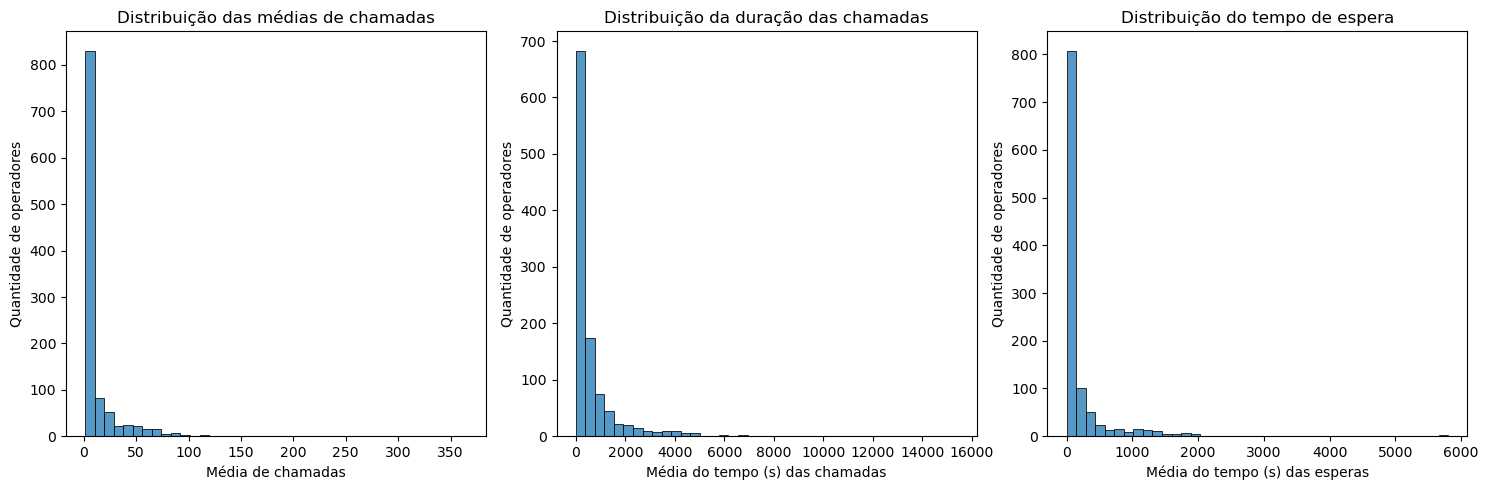

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data=op_means, x= 'mean_count',bins= 40, ax=axes[0])
sns.histplot(data=op_means, x= 'mean_duration', bins= 40, ax=axes[1])
sns.histplot(data=op_means, x= 'mean_duration_hold',bins= 40, ax=axes[2])

axes[0].set_title('Distribuição das médias de chamadas')
axes[0].set_ylabel('Quantidade de operadores')
axes[0].set_xlabel('Média de chamadas')
axes[1].set_title('Distribuição da duração das chamadas')
axes[1].set_ylabel('Quantidade de operadores')
axes[1].set_xlabel('Média do tempo (s) das chamadas')
axes[2].set_title('Distribuição do tempo de espera')
axes[2].set_ylabel('Quantidade de operadores')
axes[2].set_xlabel('Média do tempo (s) das esperas')

plt.tight_layout()
plt.show()

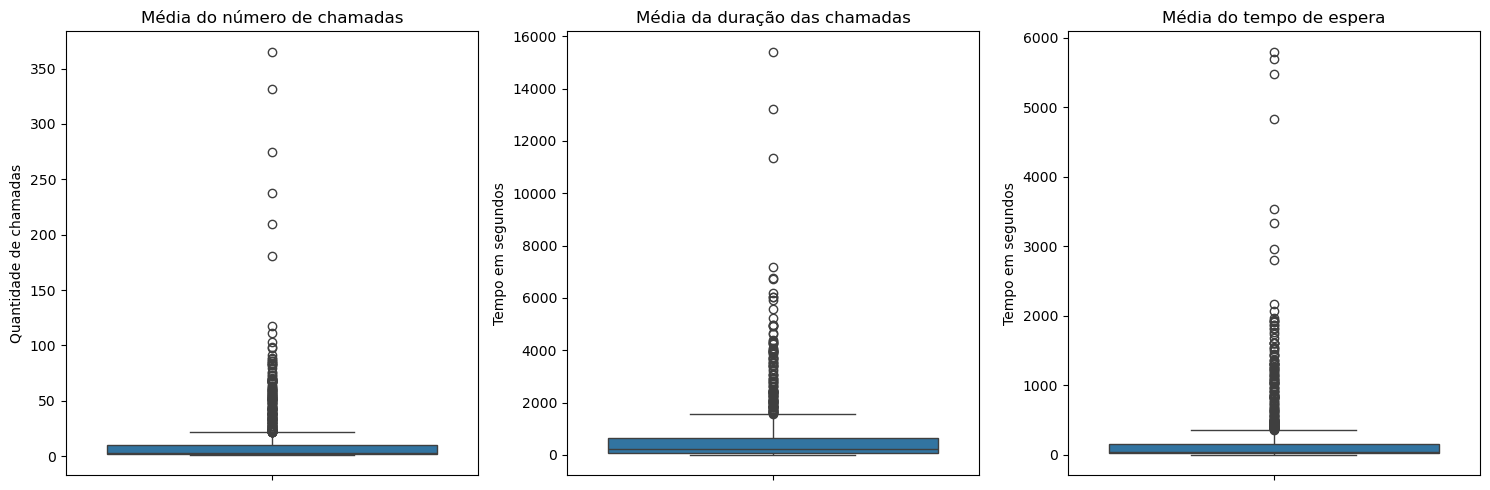

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=op_means, y= 'mean_count',ax=axes[0])
sns.boxplot(data=op_means, y= 'mean_duration',ax=axes[1])
sns.boxplot(data=op_means, y= 'mean_duration_hold',ax=axes[2])

axes[0].set_title('Média do número de chamadas')
axes[0].set_ylabel('Quantidade de chamadas')
axes[1].set_title('Média da duração das chamadas')
axes[1].set_ylabel('Tempo em segundos')
axes[2].set_title('Média do tempo de espera')
axes[2].set_ylabel('Tempo em segundos')

plt.tight_layout()
plt.show()


Tanto os histogramas quanto os gráficos em caixa revelam a mesma situação:</br>
A existência de outliers nos dados influenciaram muito as métricas traçadas anteriormente.</br>
Possivelmente esses outliers são operadores especializados em determinadas tarefas que ampliam seu desempenho.</br>
Para os gráficos logo abaixo, esses outliers serão temporariamente desconsiderados para que seja traçada uma métrica mais ajustada a maioria.

In [44]:
colunas = ['mean_count', 'mean_duration', 'mean_duration_hold']
op_means_limpo = op_means.copy()

for coluna in colunas:    
    Q1 = op_means_limpo[coluna].quantile(0.25)
    Q3 = op_means_limpo[coluna].quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    
    op_means_limpo = op_means_limpo[op_means_limpo[coluna] <= lim_sup]

In [46]:
print(op_means_limpo.describe())
print('')
print(f"Total de operadores outliers desconsiderados: {len(op_means) - len(op_means_limpo)}. Equivalente a {len(op_means) / len(op_means_limpo *100):.2f}% dos dados.")

       mean_count  mean_duration  mean_duration_hold
count  781.000000     781.000000          781.000000
mean     2.735994     198.831539           40.157372
std      2.017973     193.336577           31.341490
min      1.000000       0.000000            0.000000
25%      1.347826      51.333333           18.142857
50%      2.000000     142.347826           30.454545
75%      3.333333     292.351351           53.020000
max     16.000000     925.142857          140.400000

Total de operadores outliers desconsiderados: 311. Equivalente a 1.40% dos dados.


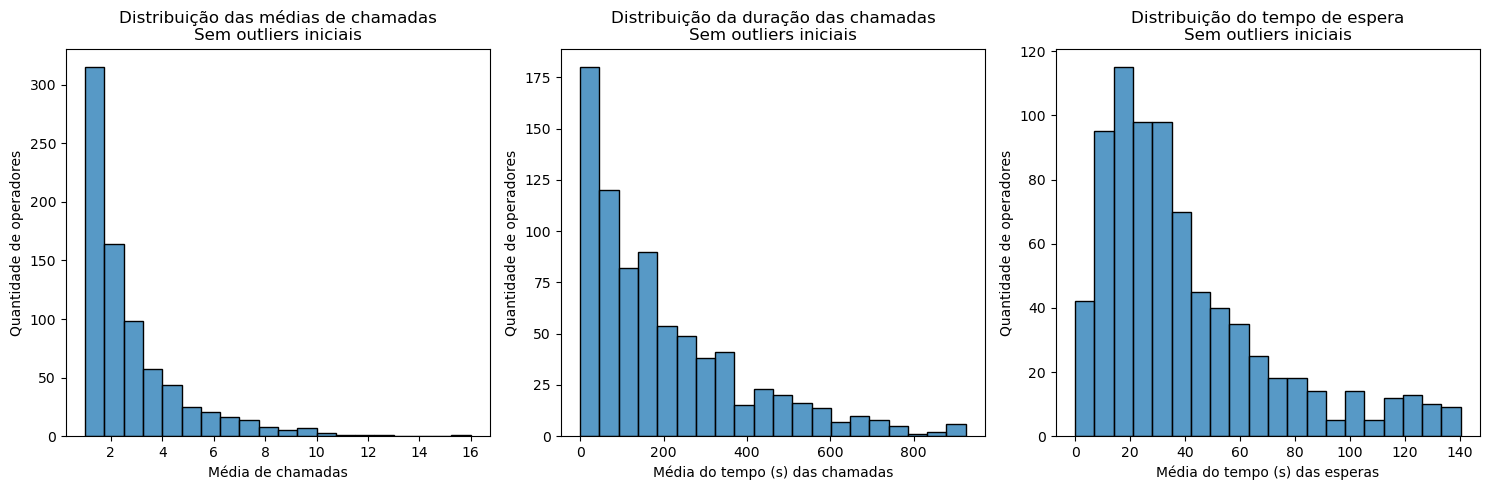

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data=op_means_limpo, x= 'mean_count',bins= 20, ax=axes[0])
sns.histplot(data=op_means_limpo, x= 'mean_duration', bins= 20, ax=axes[1])
sns.histplot(data=op_means_limpo, x= 'mean_duration_hold',bins= 20, ax=axes[2])

axes[0].set_title('Distribuição das médias de chamadas\nSem outliers iniciais')
axes[0].set_ylabel('Quantidade de operadores')
axes[0].set_xlabel('Média de chamadas')
axes[1].set_title('Distribuição da duração das chamadas\nSem outliers iniciais')
axes[1].set_ylabel('Quantidade de operadores')
axes[1].set_xlabel('Média do tempo (s) das chamadas')
axes[2].set_title('Distribuição do tempo de espera\nSem outliers iniciais')
axes[2].set_ylabel('Quantidade de operadores')
axes[2].set_xlabel('Média do tempo (s) das esperas')

plt.tight_layout()
plt.show()

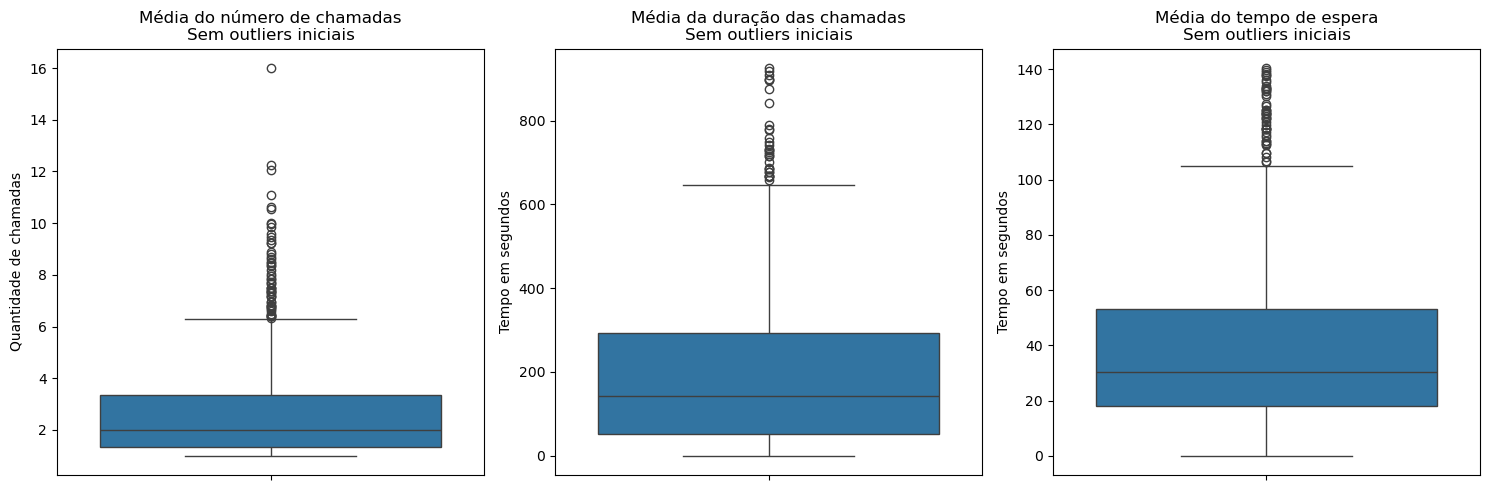

In [48]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=op_means_limpo, y= 'mean_count',ax=axes[0])
sns.boxplot(data=op_means_limpo, y= 'mean_duration',ax=axes[1])
sns.boxplot(data=op_means_limpo, y= 'mean_duration_hold',ax=axes[2])

axes[0].set_title('Média do número de chamadas\nSem outliers iniciais')
axes[0].set_ylabel('Quantidade de chamadas')
axes[1].set_title('Média da duração das chamadas\nSem outliers iniciais')
axes[1].set_ylabel('Tempo em segundos')
axes[2].set_title('Média do tempo de espera\nSem outliers iniciais')
axes[2].set_ylabel('Tempo em segundos')

plt.tight_layout()
plt.show()


Agora sem os outliers que esticavam as métricas para cima, vemos com melhor distinção os histogramas e as caixas.
Nos histogramas vemos que os operadores realmente operaram poucas chamadas, em média menos que 3. Com duração média menor que 4 minutos e o tempo de espera por volta de 40 segundos.
Nos gráficos em caixa, conseguimos perceber os outliers desse grupo já reduzido. Ainda assim, esses operadores não ultrapassaram a média de 20 chamadas nem os 16 minutos de duração.

In [49]:
# análise de operadores pela direção das chamadas
op_in_out = (telecom_dataset.groupby(['operator_id', 'direction'])['calls_count'].sum().unstack(fill_value=0))

op_in = op_in_out[op_in_out['in'] >= op_in_out['out']]
op_out = op_in_out[op_in_out['out'] > op_in_out['in']]

print(f"Operadores com mais chamadas de entrada: {len(op_in)}.")
print('')
print(f"Operadores com mais chamadas de saída: {len(op_out)}.")

Operadores com mais chamadas de entrada: 357.

Operadores com mais chamadas de saída: 735.


Olhando para a quantidade de chamadas de saída e entrada de cada operadores, podemos separar por quem realiza mais chamadas do que recebe e vice-versa.</br>
Assim vemos que 735 operadores fazem mais chamadas do que recebem. Podemos deduzir suas funções no setor com estes números, se o operador é responsável por fazer ou receber chamadas.

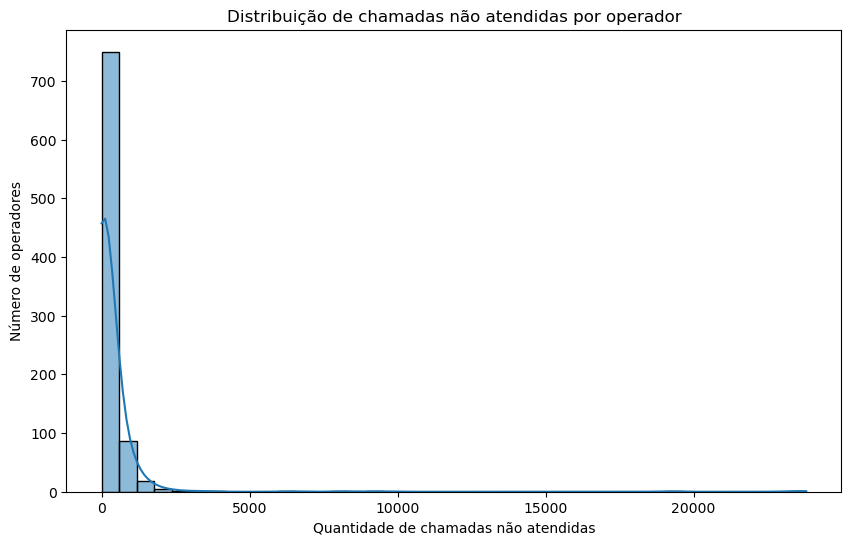

In [50]:
plt.figure(figsize=(10,6))
sns.histplot(telecom_dataset[telecom_dataset['is_missed_call'] == True].groupby('operator_id')['calls_count'].sum(),bins=40, kde=True)

plt.xlabel('Quantidade de chamadas não atendidas')
plt.ylabel('Número de operadores')
plt.title('Distribuição de chamadas não atendidas por operador')

plt.show()


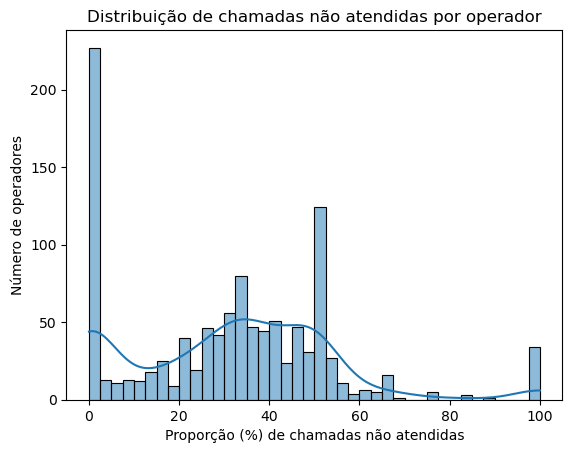

In [51]:
sns.histplot(telecom_dataset.groupby('operator_id')['is_missed_call'].mean()*100, bins=40, kde=True)

plt.xlabel('Proporção (%) de chamadas não atendidas')
plt.ylabel('Número de operadores')
plt.title('Distribuição de chamadas não atendidas por operador')

plt.show()

Com estes dois últimos histogramas, vemos primeiro a distribuição da quantidade de operadores com chamadas não atendidas e quantas chamadas foram.</br>
No segundo histograma, vemos a proporção das chamadas atendidas e não atendidas.</br>
Quanto menor a proporção, mais chamadas atendidas e menos não atendidas.

#### Conclusão Etapa 2.
Com estas análises, vimos que foi preciso limpar mais os dados para chegar a conclusões mais claras.</br>
Depois de traçar as métricas por operador, notou-se a existência de outliers que enganavam a média geral dos números. Esses outliers foram removidos e os gráficos foram refeitos com os valores atualizados.</br>
A interpretação de cada gráfico segue junto com a imagem para melhor compreensão

### Etapa 3. Testes de hipóteses

#### Hipótese 1. 
O tempo de espera médio é igual entre os operadores (H0) / Há quem demore mais para atender as chamadas (H1).

In [52]:
hip_1 = telecom_dataset[(telecom_dataset['direction'] == 'in') & (telecom_dataset['is_missed_call'] == False)].copy()
hip_1['mean_hold'] = (hip_1['duration_hold'] / hip_1['calls_count'])

In [53]:
resultado_hip_1 = kruskal(*[grupo['mean_hold'] for _, grupo in hip_1.groupby('operator_id')])

print(resultado_hip_1)
print('')
if resultado_hip_1.pvalue < 0.05:
    print('Rejeitamos a hipótese nula. Há quem demore mais para atender as chamadas.')
else:
    print('Não podemos rejeitar a hipótese nula. Os tempos médios de espera podem ser iguais entre os operadoes')

KruskalResult(statistic=np.float64(8479.631221891828), pvalue=np.float64(0.0))

Rejeitamos a hipótese nula. Há quem demore mais para atender as chamadas.


Text(0, 0.5, 'Tempo em segundos')

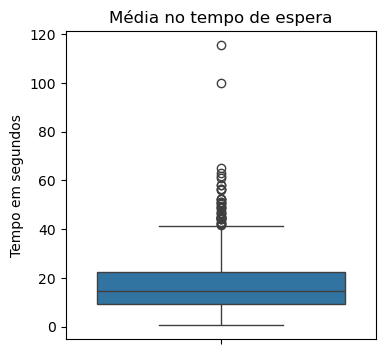

In [54]:
plt.figure(figsize=(4,4))
sns.boxplot(data= hip_1.groupby('operator_id')['mean_hold'].mean().reset_index(), y= 'mean_hold')
plt.title('Média no tempo de espera')
plt.ylabel('Tempo em segundos')

In [55]:
print(hip_1.groupby('operator_id')['mean_hold'].mean().sort_values().head(3))
print('')
print(hip_1.groupby('operator_id')['mean_hold'].mean().sort_values().tail(3))

operator_id
940442.0    0.653260
949420.0    0.750000
952982.0    0.833333
Name: mean_hold, dtype: float64

operator_id
907174.0     65.1875
917680.0    100.0000
905842.0    115.5000
Name: mean_hold, dtype: float64


#### Conclusão hipótese 1
Agregando por operador com as chamadas recebidas e atendidas, analisamos o tempo de espera para atender a ligação.</br>
Há operadores que se destacam e nesse caso é negativamente. Enquanto há operadores com média de demora de menos de 1 segundo para atender, há operadores com médias acima de 90 segundos.

#### Hipótese 2.
A razão de chamadas não atendidas é igual entre os operadores (H0) / Há quem perca mais chamadas (H1).

In [56]:
hip_2 = telecom_dataset[telecom_dataset['direction'] == 'in'].copy()
hip_2['missed_count'] = np.where(hip_2['is_missed_call'] == True, hip_2['calls_count'], 0)
hip_2['ratio'] = (hip_2['missed_count'] / hip_2['calls_count']) * 100

In [57]:
resultado_hip_2 = kruskal(*[grupo['ratio'] for _, grupo in hip_2.groupby('operator_id')])

print(resultado_hip_2)
print('')
if resultado_hip_2.pvalue < 0.05:
    print('Rejeitamos a hipótese nula. Há quem perca mais chamadas proporcionalmente.')
else:
    print('Não podemos rejeitar a hipótese nula. A razão de chamadas não atendidas pode ser igual entre os operadores.')

KruskalResult(statistic=np.float64(1148.239672221734), pvalue=np.float64(5.62876747838941e-19))

Rejeitamos a hipótese nula. Há quem perca mais chamadas proporcionalmente.


Text(0.5, 0, 'Proporção (%)')

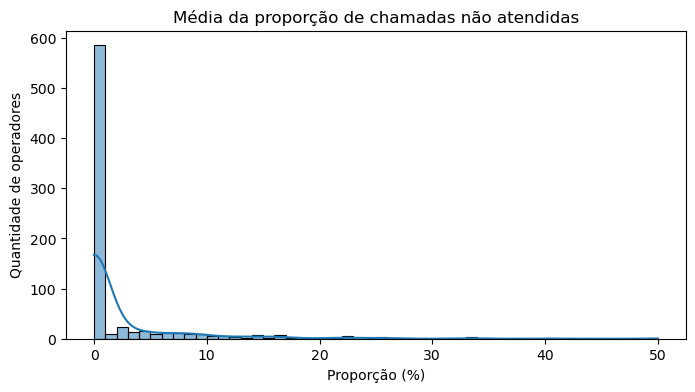

In [58]:
plt.figure(figsize=(8,4))
sns.histplot(data= hip_2.groupby('operator_id')['ratio'].mean().reset_index(), x= 'ratio', bins= 50, kde= True)
plt.title('Média da proporção de chamadas não atendidas')
plt.ylabel('Quantidade de operadores')
plt.xlabel('Proporção (%)')

In [59]:
print(hip_2.groupby('operator_id')['ratio'].mean().sort_values().tail(10))

operator_id
930242.0    25.000000
941844.0    25.000000
944216.0    25.490196
944226.0    26.000000
919204.0    26.666667
898414.0    33.333333
897872.0    33.333333
937432.0    33.333333
934098.0    40.000000
957922.0    50.000000
Name: ratio, dtype: float64


#### Conclusão hipótese 2
A razão de chamadas não atendidas foi calculando somando o total de chamadas não atendidas e dividindo pelo total de chamadas de cada operador.</br>
O resultado do teste de Kruskal-Wallis nos diz que a há quem tenha maiores proporções na perda de chamadas.</br>
E como vemos no histograma, a maioria dos operadores tem uma média de proporção baixa mas há aqueles que ultrapassam 25% de chamadas não atendidas.

#### Hipótese 3.
Os operadores tem a mesma contagem de chamadas realizadas (H0) / Há operadores que fogem o padrão da quantidade de chamadas realizadas (H1).

In [60]:
hip_3 = telecom_dataset[(telecom_dataset['operator_id'].isin(op_out.index)) & (telecom_dataset['direction'] == 'out')]

In [61]:
resultado_hip_3 = kruskal(*[grupo['calls_count'] for _, grupo in hip_3.groupby('operator_id')])

print(resultado_hip_3)
print('')
if resultado_hip_3.pvalue < 0.05:
    print('Rejeitamos a hipótese nula. Há operadores que fogem o padrão da quantidade de chamadas realizadas.')
else:
    print('Não podemos rejeitar a hipótese nula. A contagem de chamadas de saída podem ser a mesma.')

KruskalResult(statistic=np.float64(13980.070403821699), pvalue=np.float64(0.0))

Rejeitamos a hipótese nula. Há operadores que fogem o padrão da quantidade de chamadas realizadas.


Text(0.5, 0, 'Quantidade de chamadas')

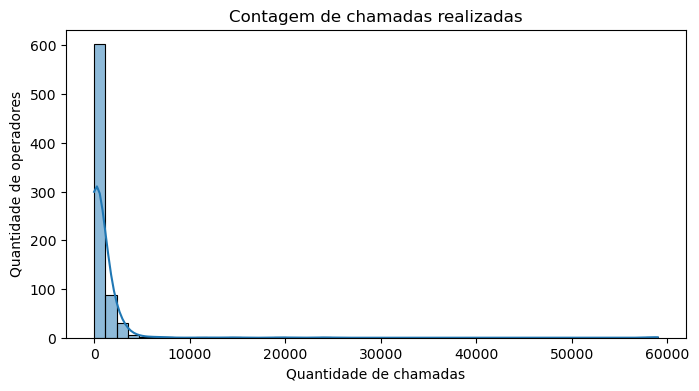

In [62]:
plt.figure(figsize=(8,4))
sns.histplot(data= hip_3.groupby('operator_id')['calls_count'].sum().reset_index(), x= 'calls_count', bins= 50, kde= True)
plt.title('Contagem de chamadas realizadas')
plt.ylabel('Quantidade de operadores')
plt.xlabel('Quantidade de chamadas')

#### Conclusão hipótese 3
Para esta hipótese foram considerados apenas os registros de chamadas realizadas e de operadores caracterizados por efetuarem mais chamadas do que recebê-las.</br>
Pelo resultado do teste e o histograma acima, vemos que os operadores não seguem o mesmo padrão. Ou seja, há operadores que se destacam, positivamente neste caso, por realizaram muito mais chamadas do que o restante dos operadores.

#### Conclusão Etapa 3.
Os 3 testes de hipótese foram realizados seguindo o protocolo Kruskal-Wallis.</br>
O Teste de Kruskal é indicado para quando os dados não seguem a distribuição normal. No nosso caso, os dados filtrados para testar as hipóteses tinham uma cauda prolongada indicando muitos outliers. Para além disso, Kruskal se aproveita da quantidade de observações registradas por *operator_id* para se fazer valer.</br>
</br>
Ao fim dos testes, todas as 3 hipóteses alternativas (H1) foram consideradas como possíveis.</br>
O próximo passo é agrupar os operadores com índices ruins para identificá-los.

### Etapa 4. Entrega de resultados

In [63]:
# operadores denunciados pela hipótese 1 (tempo de espera)
r_1_ = hip_1.groupby('operator_id')['mean_hold'].mean().reset_index()
print(r_1_['mean_hold'].describe())
r_1 = r_1_[r_1_['mean_hold'] >= r_1_['mean_hold'].quantile(0.75)] # selecionando o 4º quartil (25% mais alto)
r_1 = r_1['operator_id'].tolist()
print('')
print(f"Para o grupo com maiores tempo de espera são: {len(r_1)} operadores.")

count    754.000000
mean      17.655614
std       12.265235
min        0.653260
25%        9.410714
50%       14.464286
75%       22.357143
max      115.500000
Name: mean_hold, dtype: float64

Para o grupo com maiores tempo de espera são: 189 operadores.


In [64]:
# operadores denunciados pela hipótese 2 (não-atendidas)
r_2_ = hip_2.groupby('operator_id')['ratio'].mean().reset_index()
print(r_2_['ratio'].sort_values().tail())
r_2 = r_2_[r_2_['ratio'] >= 10] # selecionando médias a partir de 10%
r_2 = r_2['operator_id'].tolist()
print('')
print(f"Para o grupo com maiores proporções de chamadas perdidas: {len(r_2)} operadores.")

110    33.333333
109    33.333333
497    33.333333
467    40.000000
698    50.000000
Name: ratio, dtype: float64

Para o grupo com maiores proporções de chamadas perdidas: 53 operadores.


In [65]:
# operadores denunciados pela hipótese 3 (chamadas efetuadas)
r_3_ = hip_3.groupby('operator_id')['calls_count'].sum().reset_index()
print(r_3_['calls_count'].describe())
r_3 = r_3_[r_3_['calls_count'] <= r_3_['calls_count'].quantile(0.25)] # selecionando o 1º quartil (25% mais baixo)
r_3 = r_3['operator_id'].tolist()
print('')
print(f"Para o grupo com menos chamadas efetuadas: {len(r_3)} operadores.")

count      735.000000
mean       817.625850
std       3406.599887
min          1.000000
25%         19.000000
50%        161.000000
75%        782.500000
max      58977.000000
Name: calls_count, dtype: float64

Para o grupo com menos chamadas efetuadas: 190 operadores.


In [66]:
# operadores em mais de uma lista
r_1_2 = (set(r_1) & set(r_2)) - set(r_3)
r_1_3 = (set(r_1) & set(r_3)) - set(r_2)
r_2_3 = (set(r_2) & set(r_3)) - set(r_1)
r_123 = set(r_1) & set(r_2) & set(r_3)
r_nunique = set(r_1) | set(r_2) | set(r_3)

print(f"Operadores presentes nos grupos 1 e 2: {len(r_1_2)} operadores.")
print(f"Operadores presentes nos grupos 1 e 3: {len(r_1_3)} operadores.")
print(f"Operadores presentes nos grupos 2 e 3: {len(r_2_3)} operadores.")
print(f"Operadores presentes nos 3 grupos: {len(r_123)} operadores.")
print(f"Total de operadores selecionados: {len(r_nunique)}.")

Operadores presentes nos grupos 1 e 2: 13 operadores.
Operadores presentes nos grupos 1 e 3: 22 operadores.
Operadores presentes nos grupos 2 e 3: 4 operadores.
Operadores presentes nos 3 grupos: 0 operadores.
Total de operadores selecionados: 393.


#### Conclusão Etapa 4.
Para cada hipótese testada na Etapa 3, <u>foram criadas listas com os operadores com os piores índices</u>.</br>
</br>
O grupo 1 foi filtrado por chamadas recebidas e atendidas. Os 25% dos operadores com maiores médias em tempos de espera foram selecionados. Essa média supera os 22 segundos de espera.</br>
**Grupo 1 (tempo de espera) contém 189 operadores.**</br>
</br>
O grupo 2 foi filtrado por chamadas recebidas e a proporção foi calculada dividindo a quantidade de não atendidas pelo total de chamadas. Os operadores que obtiveram uma média de proporções acima de 10% foram selecionados.</br>
**Grupo 2 (não atendidas) contém 53 operadores.**</br>
</br>
O grupo 3 foi filtrado por operadores com mais chamadas efetuadas que recebidas, entendendo-se que isso caracteriza os operadores responsáveis por receber chamadas, e as chamadas filtradas por realizadas. O total de chamadas foi calculado por operador e os 25% com menos chamadas foram selecionados.</br>
**Grupo 3 (chamadas efetuadas) contém 190 operadores.**</br>
</br>
Há também operadores presentes em dois desses grupos, mas nenhum que esteja nos três.

## Conclusões e recomendações
Após os dados serem tratados além do que especificado na Decomposição da Tarefa e ter sido realizada a EDA, os testes de hipóteses foram executados sendo concluído que existem comportamentos diferentes para os operadores nas 3 situações analisadas.</br>
O mais importante e também o objetivo desta Tarefa é que foi possível criar grupos distintos para segregar os operadores com piores desempenhos em cada uma das situações testadas.</br>
Os operadores identificados como os de desempenhos menos expressivos são ao todo 393.</br>
</br>
A recomendação é disponibilizar sessões de treino voltadas a área de dificuldade dos operadores, conforme disponibilidade da CallMeMaybe.</br>
Outra recomendação é limitar as funções, assim evitando que operadores que realizam mais chamadas demorem a atender chamadas recebidas, por exemplo.

In [ ]:
import os
os.getcwd()

'c:\\Users\\Utilizador\\Desktop\\Daniel\\TripleTen\\Projeto_Final'

: 

In [ ]:
telecom_dataset.to_csv(r'c:\Users\Utilizador\Desktop\Daniel\TripleTen\Projeto_Final\telecom_dataset_clean.csv', index=False)

: 